## Figures 5b and 5d — Stationary modes in a finite QHO box

This notebook reproduces **Figures 5b and 5d** of the paper.

A finite box of length $L = P\lambda$ with Dirichlet boundary conditions and
a piecewise-parabolic Helmholtz coefficient $F(x)$ (the QHO medium) admits
exactly $P$ discrete eigenfrequencies per pass band, which become nearly
degenerate in the narrow-pass-band limit and converge to
$\omega_n \approx (n+\tfrac{1}{2})\,\omega_0$.


In [7]:
import numpy as np
import itertools
import scipy.special as sp
from scipy.sparse import diags
from scipy.optimize import fsolve
from scipy.sparse.linalg import eigs
from scipy.linalg import eigh
from scipy.special import mathieu_a, mathieu_cem, mathieu_b, mathieu_sem
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.stats import linregress
from numpy import linalg as LA
import scipy.linalg
import cmath as cm
import matplotlib.pyplot as plt

### QHO medium setup — $F(x)$ profile and helper functions

Defines the piecewise-parabolic base function $f_{\mathrm{base}}(x)$
and its physical counterpart $F(x)$ in SI units, then plots one period
as a visual reference.


1 1.4


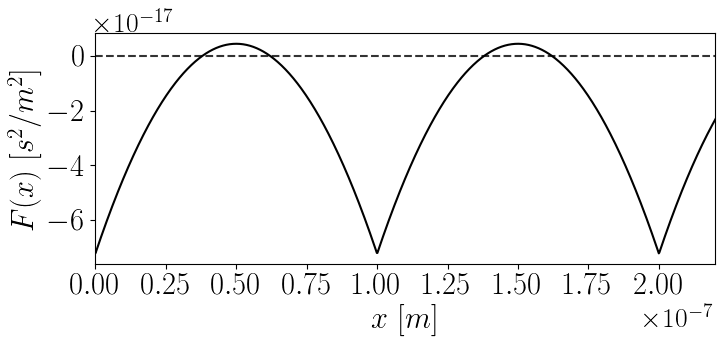

In [8]:
# Define the base function over [0, pi]
def f_base(x, ala, qlq):
    return (ala+2*qlq-4*qlq*(x-np.pi/2)**2)

def f_base_physical(x, C0, C1, lamb):
    return (C0+C1)-2*C1*(np.pi/lamb)**2*(x-lamb/2)**2



#ymax = 1.05*np.max(np.pi*np.sqrt(aap)/np.sqrt(np.abs(s0))/lamb)
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
lamb = 100e-9
kmax = 2e8
vv = 299792458
#vv = vv + 15700000

pent = 1.4
alph2 = 1
bet2 = pent*alph2
s0 = -alph2*eps0*mu0

C0 = -1/vv**2
C1 = 1.4*np.abs(C0)

print(alph2,bet2)

xshift = lamb
xplot = np.array(np.linspace(-lamb*2,lamb*2,2000))+xshift
yplot = f_base_physical(xplot %lamb,C0,C1,lamb)


fonty = 22
fig1 = plt.figure(1, figsize=(8, 3))
plt.rc('text', usetex=True)

plt.plot(xplot,yplot,'k-')
#plt.axvline(x=xshift, color='r', linestyle='--', alpha=0.8)
#plt.axvline(x=lamb+xshift, color='r', linestyle='--', alpha=0.8)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.8)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$x$ $[m]$',fontsize=fonty)
plt.ylabel(r'$F(x)$ $[s^2/m^2]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#plt.xlim(-lamb/5+xshift, lamb+lamb/5+xshift)   # set the ylim to ymin, ymax
plt.xlim(0, 2*lamb+lamb/5)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
#plt.ylim(-0.4e-9, 2e-11)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig1 = plt.gcf()
plt.show()

fig1.savefig('Modulation_negative_HQO.png', format='png', dpi=1000, bbox_inches='tight')




### Finite-box ODE solver (indefinite-weight slab)

Implements the shooting/transfer-matrix method to find eigenfrequencies
of the QHO wave equation with Dirichlet BCs on a domain of length $L = P\lambda$.


In [9]:
"""
Indefinite‑weight slab  (ε sign‑changing)
----------------------------------------

Solves  −Φ'' = omega² F(x) Φ   with F(x) that takes BOTH signs.
Dirichlet at x=0 and x=L=m·λ.

Algorithm:
  * build stiffness T and mass M (diagonal, sign‑changing);
  * solve   (M⁻¹ T) Φ = λ Φ   with NumPy's dense eig;
  * keep real, positive eigen‑values   omeg0 = √λ;
  * group into m‑sized “bands’’;
  * verify indefinite orthogonality   ∫ F Φ_m Φ_n dx = 0 for m≠n
    (diagonal entries may be ±1).

Only NumPy + Matplotlib used.
"""

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig, inv

# --- Define the profile directly on [0, λ] ---
def f_base_physical(x, C0, C1, lamb):
    return (C0 + C1) - 2 * C1 * (np.pi / lamb)**2 * (x - lamb / 2)**2


def slab_indefinite(C0, C1, lam, m, ppp, n_bands):
    L   = m*lam
    Nx  = 4*ppp + 1
    #Nx  = m*ppp + 1
    x   = np.linspace(0.0, L, Nx)
    dx  = x[1] - x[0]

    # permittivity profile (sign‑changing)
    FFF = f_base_physical(x % lam, C0, C1, lam)
    #FFF = C0 + C1*np.cos(2*np.pi*x/lam)
    if np.all(FFF > 0) or np.all(FFF < 0):
        raise ValueError("Choose C1 so that F(x) changes sign.")

    # stiffness matrix T (Dirichlet interior)
    Nint = Nx - 2
    main =  2.0*np.ones(Nint)/dx**2
    off  = -1.0*np.ones(Nint-1)/dx**2
    T    = np.diag(main) + np.diag(off,1) + np.diag(off,-1)

    # mass matrix M  (diagonal, possibly negative)
    M    = np.diag(FFF[1:-1])
    A    = inv(M) @ T                       # standard but NOT symmetric

    # ----- dense eigen‑solve (general complex) ------------------------
    lam_vals, vec = eig(A)                 # λ may come out complex
    # keep only eigen‑values with tiny imaginary part and λ>0
    tol_im = 1e-10
    #mask   = (np.abs(lam_vals.imag) < tol_im) & (lam_vals.real > 0)
    #lam_r  = lam_vals.real[mask]
    #vec_r  = vec[:, mask]
    lam_r  = lam_vals.real
    vec_r  = vec

    # sort by increasing k0
    idx    = np.argsort(np.sqrt(lam_r))
    lam_r  = lam_r[idx]
    vec_r  = vec_r[:, idx]

    need   = n_bands * m
    lam_r, vec_r = lam_r[:need], vec_r[:, :need]

    # build full Φ with boundary zeros
    Phi = np.zeros((Nx, need))
    Phi[1:-1, :] = vec_r

    # normalise in the indefinite inner product  <f,f>ε = ±1
    sign_diag = np.trapz(FFF[:,None]*Phi**2, x, axis=0)
    Phi /= np.sqrt(np.abs(sign_diag))       # gives ±1 norms
    
    
# --- NEW: ε‑weighted Gram–Schmidt to clean up near‑degenerate modes ---
    for j in range(Phi.shape[1]):
        v = Phi[:, j]
        for k in range(j):                                  # subtract proj
            v -= np.trapz(FFF * Phi[:, k] * v, x) * Phi[:, k]
        v /= np.sqrt(np.abs(np.trapz(FFF * v * v, x)))      # renormalise
        Phi[:, j] = v
    
    omeg0  = np.sqrt(lam_r)
    bands = [slice(i*m, (i+1)*m) for i in range(n_bands)]
    
    S = np.trapz(FFF[:,None,None]*Phi[:,:,None]*Phi[:,None,:], x, axis=0)
    print("max |S_nn−1| =", np.max(np.abs(np.diag(S)-1)))
    print("max |S_nm| (n≠m) =", np.max(np.abs(S-np.diag(np.diag(S)))))    
    
    # ---------------- split into consecutive blocks of length m --------
    o0_bands  = [omeg0[i*m:(i+1)*m]        for i in range(n_bands)]
    Phi_bands = [Phi[:, i*m:(i+1)*m]    for i in range(n_bands)]
    
    
    return x, FFF, o0_bands, Phi_bands, bands, sign_diag


### → Figure 5b — Stationary modes in a one-wavelength box ($P = 1$)

Solves for the discrete eigenfrequencies and plots the stationary mode shapes
inside a box of length $L = \lambda$, together with the eigenvalue spectrum.
Produces `Modesfinite_quantum_onewavelength.png` and `Eigenvalue_problem_HQO_1.png`.


/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_24440/2374624806.py:62: RuntimeWarning: invalid value encountered in sqrt
  idx    = np.argsort(np.sqrt(lam_r))
/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_24440/2374624806.py:71: ComplexWarning: Casting complex values to real discards the imaginary part
  Phi[1:-1, :] = vec_r


max |S_nn−1| = 4.440892098500626e-15
max |S_nm| (n≠m) = 3.363312325055329e-16
[array([3.93997989e+16]), array([1.18199008e+17]), array([1.96997166e+17]), array([2.75793551e+17])]
3.939981714217616e+16 1.181994514265285e+17 1.9699908571088083e+17 2.7579871999523318e+17 3.545983542795855e+17 4.333979885639378e+17
24.500000000000007
Periodic slab: C0 = -1.1126264540484579e-17,  C1 = 1.557677035667841e-17,  λ = 1e-07
Pass‑band  1:  o0 = [39399798898564552.00000]
Pass‑band  2:  o0 = [118199008386269472.00000]
Pass‑band  3:  o0 = [196997165878591008.00000]
Pass‑band  4:  o0 = [275793551220270464.00000]


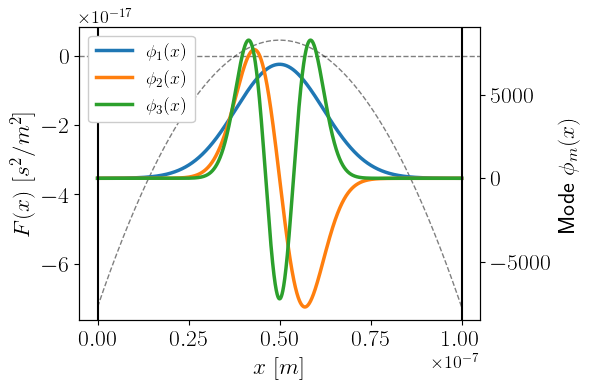

0
1
2
3


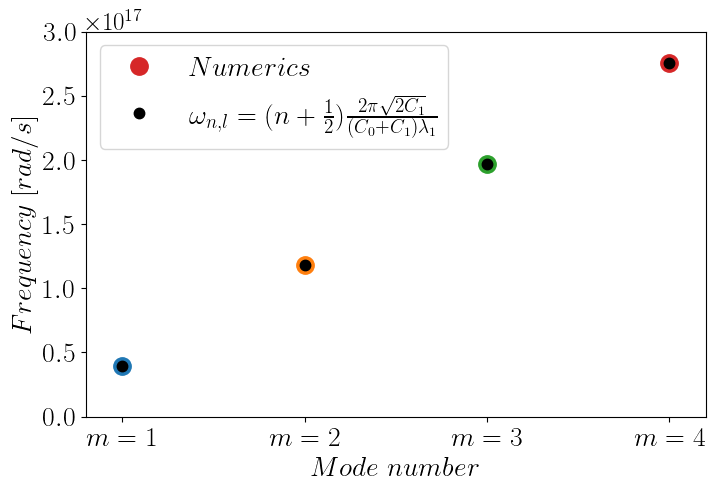

In [10]:
from matplotlib.ticker import ScalarFormatter

# ---------------- parameters ------------------------------------------
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
lam        = 100e-9            # period
m          = 1              # periods  -> m modes per band
n_bands    = 4              # how many bands to keep
ppp        = 600            # grid density
C0       =  -eps0*mu0          # background -1.5 was the first value
C1       = 1.4*np.abs(C0)           # modulation (gives ε min ≈ -1.5 < 0)
# ----------------------------------------------------------------------

# ---------------- run --------------------------------------------------
x, FFF, o0_bands, Phi_bands, bands, sig = slab_indefinite(
        C0, C1, lam, m, ppp, n_bands)

#print(np.concatenate(o0_bands))

print(o0_bands)

omegana0 = 0.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana1 = 1.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana2 = 2.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana3 = 3.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana4 = 4.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana5 = 5.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
print(omegana0,omegana1,omegana2,omegana3,omegana4,omegana5)

qq0 = C1*omegana0**2*lam**2/(2*np.pi**2)
print(2*qq0)

# ---- print nice summary ------------------------------------------
print(f"Periodic slab: C0 = {C0},  C1 = {C1},  λ = {lam}")
for b, olist in enumerate(o0_bands, start=1):
    txt = ", ".join(f"{oo:.5f}" for oo in olist)
    print(f"Pass‑band {b:>2d}:  o0 = [{txt}]")

# --- Plot first N modes along with F(x) on a twin y-axis
N = 4  # Number of modes to plot
#FFF = f_base_physical(x % lam, C0, C1, lam)



fonty = 17
fig, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)

# Plot the first N modes from flattened Phi_bands
Phi_all = np.hstack(Phi_bands)  # shape: (Nx, total_modes)

# ---------- Make an L2-rescaled copy (per column only) ----------
# Use simple trapz for L2; (optionally) trapezoid weights W if you prefer.
l2 = np.sqrt(np.trapz(Phi_all**2, x, axis=0))   # shape (K,)
Phi_L2 = Phi_all / l2                           # still exact eigenvectors



# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)  
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
for n in range(N - 1):
    line, = ax1.plot(x, Phi_L2[:, n],
                     label=fr"$\phi_{n+1}(x)$",
                     linewidth=2.5)
    lines.append(line)
    
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'Mode $\phi_m(x)$', fontsize=fonty)
ax1.legend(
    loc="upper left",
    fontsize=fonty-4,
    facecolor='white',   # solid white background
    framealpha=1.0       # fully opaque
)

ax1.set_xlim(-100e-9*0.05, 100e-9+100e-9*0.05)


#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)


# Add box boundaries
ax1.axvline(0, color="black", lw=1.5)
ax1.axvline(m*lam, color="black", lw=1.5)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig.savefig('Modesfinite_quantum_onewavelength.png', format='png', dpi=1000, bbox_inches='tight')






fonty = 20
fig4 = plt.figure(4, figsize=(8, 5))
plt.rc('text', usetex=True)

for b, olist in enumerate(o0_bands, start=0):
    print(b)
    for oo in olist:
        if b < N-1:
            color = lines[b].get_color()  # match mode color
            plt.plot(b,oo,'.',markersize=25., alpha=1,color=color)
        else:
            plt.plot(b,oo,'.',markersize=25., alpha=1,color='tab:red',label=r'$Numerics$')

plt.plot(0,omegana0,'k.',markersize=15,label=r'$\omega_{n,l}=(n+\frac{1}{2})\frac{2\pi\sqrt{2C_1}}{(C_0+C_1)\lambda_1}$')
plt.plot(1,omegana1,'k.',markersize=15)
plt.plot(2,omegana2,'k.',markersize=15)
plt.plot(3,omegana3,'k.',markersize=15)
plt.legend(loc="upper left",fontsize=fonty)         
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$Frequency$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(-0.2, 3.2)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., 3e17)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1,2, 3], [r'$m=1$',r'$m=2$',r'$m=3$',r'$m=4$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Eigenvalue_problem_HQO_1.png', format='png', dpi=1000, bbox_inches='tight')



### → Figure 5d — Stationary modes in a two-half-wavelength box ($L = \lambda$, $P = 2$)

Solves for the discrete eigenfrequencies in a box of length $L = \lambda = 10^{-7}$ m
containing two half-wavelength sub-cells ($P = 2$).
In the narrow-pass-band limit, the two nearly-degenerate modes per pass band
are clearly resolved. Produces `Modesfinite_quantum_twohalfwavelength.png`
and `Eigenvalue_problem_HQO_3.png`.


5e-08


/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_24440/2374624806.py:62: RuntimeWarning: invalid value encountered in sqrt
  idx    = np.argsort(np.sqrt(lam_r))


max |S_nn−1| = 1.7763568394002505e-15
max |S_nm| (n≠m) = 1.01694087956855e-15
[array([7.87986884e+16, 7.87987118e+16]), array([2.36384726e+17, 2.36384726e+17]), array([3.93936737e+17, 3.93936737e+17]), array([5.51432038e+17, 5.51432038e+17])]
7.879963428435232e+16 2.36398902853057e+17 3.9399817142176166e+17 5.5159743999046637e+17 7.09196708559171e+17 8.667959771278756e+17
24.500000000000007
Periodic slab: C0 = -1.1126264540484579e-17,  C1 = 1.557677035667841e-17,  λ = 5e-08
Pass‑band  1:  o0 = [78798688392500336.00000, 78798711756063120.00000]
Pass‑band  2:  o0 = [236384725575242144.00000, 236384725575608128.00000]
Pass‑band  3:  o0 = [393936736505124864.00000, 393936736505323392.00000]
Pass‑band  4:  o0 = [551432038248979264.00000, 551432038249309376.00000]


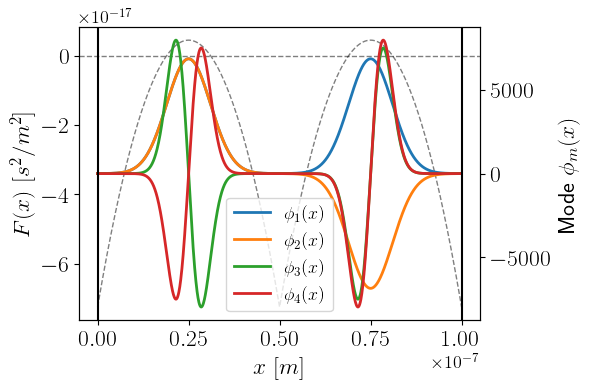

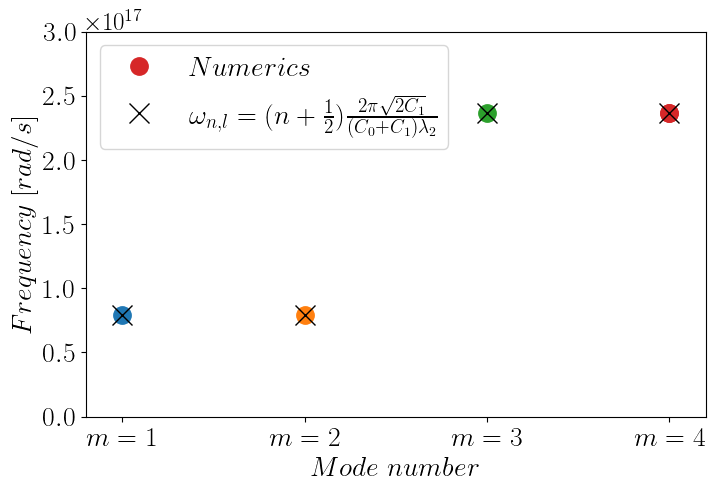

In [11]:
from matplotlib.ticker import ScalarFormatter

# ---------------- parameters ------------------------------------------
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
lam        = 50e-9            # period
m          = 2              # periods  -> m modes per band
n_bands    = 4              # how many bands to keep
ppp        = 300            # grid density
C0       =  -eps0*mu0          # background -1.5 was the first value
C1       = 1.4*np.abs(C0)           # modulation (gives ε min ≈ -1.5 < 0)
# ----------------------------------------------------------------------

print(lam)
# ---------------- run --------------------------------------------------
x, FFF, o0_bands, Phi_bands, bands, sig = slab_indefinite(
        C0, C1, lam, m, ppp, n_bands)

#print(np.concatenate(o0_bands))

print(o0_bands)


omegana0 = 0.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana1 = 1.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana2 = 2.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana3 = 3.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana4 = 4.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana5 = 5.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
print(omegana0,omegana1,omegana2,omegana3,omegana4,omegana5)

qq0 = C1*omegana0**2*lam**2/(2*np.pi**2)
print(2*qq0)


# ---- print nice summary ------------------------------------------
print(f"Periodic slab: C0 = {C0},  C1 = {C1},  λ = {lam}")
for b, olist in enumerate(o0_bands, start=1):
    txt = ", ".join(f"{oo:.5f}" for oo in olist)
    print(f"Pass‑band {b:>2d}:  o0 = [{txt}]")

# --- Plot first N modes along with F(x) on a twin y-axis
N = 4  # Number of modes to plot
#FFF = f_base_physical(x % lam, C0, C1, lam)



fonty = 17
fig, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)

# Plot the first N modes from flattened Phi_bands
Phi_all = np.hstack(Phi_bands)  # shape: (Nx, total_modes)

# ---------- Make an L2-rescaled copy (per column only) ----------
# Use simple trapz for L2; (optionally) trapezoid weights W if you prefer.
l2 = np.sqrt(np.trapz(Phi_all**2, x, axis=0))   # shape (K,)
Phi_L2 = Phi_all / l2  

# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)  
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")
    
# Store plotted lines to extract their colors
lines = []
for n in range(N):
    line, = ax1.plot(x, Phi_L2[:, n],
                     label=fr"$\phi_{n+1}(x)$",
                     linewidth=2)
    lines.append(line)
    
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'Mode $\phi_m(x)$', fontsize=fonty)
ax1.legend(loc="lower center",fontsize=fonty-4)
ax1.set_xlim(-100e-9*0.05, 100e-9+100e-9*0.05)


#ax = plt.gca()
ax2.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)

# Add box boundaries
ax1.axvline(0, color="black", lw=1.5)
ax1.axvline(m*lam, color="black", lw=1.5)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig.savefig('Modesfinite_quantum_twohalfwavelength.png', format='png', dpi=1000, bbox_inches='tight')






fonty = 20
fig4 = plt.figure(4, figsize=(8, 5))
plt.rc('text', usetex=True)

flat_array = np.concatenate(o0_bands)  # shape: (total_modes,)
for b, oo in enumerate(flat_array[0:4],start=0):
    if b < N-1:
        color = lines[b].get_color()  # match mode color
        plt.plot(b,oo,'.',markersize=25., alpha=1,color=color)
    else:
        color = lines[b].get_color()  # match mode color
        plt.plot(b,oo,'.',markersize=25., alpha=1,color=color)
        
plt.plot(b,oo,'.',markersize=25., alpha=1,color=color,label=r'$Numerics$')


plt.plot(0,omegana0,'kx',markersize=15,label=r'$\omega_{n,l}=(n+\frac{1}{2})\frac{2\pi\sqrt{2C_1}}{(C_0+C_1)\lambda_2}$')
plt.plot(1,omegana0,'kx',markersize=15)
plt.plot(2,omegana1,'kx',markersize=15)
plt.plot(3,omegana1,'kx',markersize=15)              
plt.legend(loc="upper left",fontsize=fonty)    
plt.xlabel(r'$Mode$ $number$',fontsize=fonty)
plt.ylabel(r'$Frequency$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(-0.2, 3.2)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., 3e17)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1,2, 3], [r'$m=1$',r'$m=2$',r'$m=3$',r'$m=4$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Eigenvalue_problem_HQO_3.png', format='png', dpi=1000, bbox_inches='tight')



### Stationary modes in a concatenated medium

Assembles two QHO sub-media with different characteristic frequencies
and computes the stationary modes of the concatenated system, verifying
that the spectrum is the union of the individual spectra (superposition principle).
Produces `Modesfinite_quantum_concatenate.png` and `Energy_concatenate_1.png`.


In [12]:
import numpy as np
from numpy.linalg import eig, inv
import matplotlib.pyplot as plt

# ---------- your original helper, unchanged ---------------------------
# --- Define the profile directly on [0, λ] ---
def f_base_physical(x, C0, C1, lam):
    return (C0 + C1) - 2 * C1 * (np.pi / lam)**2 * (x - lam / 2)**2


# ---------- new "concatenate" driver ----------------------------------
def slab_concat(params_A, params_B, ppp, n_bands):
    """
    Build   [ medium A | medium B ]   and solve
    Dirichlet @ x=0, x=L.
    params_* = (C0, C1, lam, m)   for each sub‑medium
    """
    # --- unpack parameters --------------------------------------------
    C0_A, C1_A, lam_A, m_A = params_A
    C0_B, C1_B, lam_B, m_B = params_B
    L_A   = m_A * lam_A
    L_B   = m_B * lam_B
    L     = L_A + L_B

    # --- global grid ---------------------------------------------------
    Nx    = int(np.round((L / lam_A) * (4*ppp))) + 1   # ≥4 points/period_A
    x     = np.linspace(0, L, Nx)
    dx    = x[1] - x[0]

    # --- piece‑wise F(x)  «« NEW »»
    FFF   = np.ones_like(x)*(C0_A+C1_A)        # air as default (ε=1) in gap + outside
    maskA = x < L_A
    maskB = x > L_A
    # Local coordinates for each medium (reset origin for periodicity)
    x_A_local = x[maskA] % lam_A
    x_B_local = (x[maskB] - L_A) % lam_B

    # Apply profiles
    FFF[maskA] = f_base_physical(x_A_local, C0_A, C1_A, lam_A)
    FFF[maskB] = f_base_physical(x_B_local, C0_B, C1_B, lam_B)    

    # ---------------- assemble stiffness & mass ------------------------
    Nint = Nx - 2                         # interior nodes only
    main =  2.0*np.ones(Nint)   / dx**2
    off  = -1.0*np.ones(Nint-1) / dx**2
    T    = np.diag(main) + np.diag(off,1) + np.diag(off,-1)   # stiffness
    M    = np.diag(FFF[1:-1])                                     # mass

    A    = inv(M) @ T                       # standard but NOT symmetric

    # ----- dense eigen‑solve (general complex) ------------------------
    lam_vals, vec = eig(A)                 # λ may come out complex
    # keep only eigen‑values with tiny imaginary part and λ>0
    tol_im = 1e-10
    mask   = (np.abs(lam_vals.imag) < tol_im) & (lam_vals.real > 0)
    lam_r  = lam_vals.real[mask]
    vec_r  = vec[:, mask]
    #lam_r  = lam_vals.real
    #vec_r  = vec

    # sort by increasing k0
    idx    = np.argsort(np.sqrt(lam_r))
    lam_r  = lam_r[idx]
    vec_r  = vec_r[:, idx]

    need   = n_bands * (m_A+m_B)
    lam_r, vec_r = lam_r[:need], vec_r[:, :need]

    # build full Φ with boundary zeros
    Phi = np.zeros((Nx, need))
    Phi[1:-1, :] = vec_r

    # normalise in the indefinite inner product  <f,f>ε = ±1
    sign_diag = np.trapz(FFF[:,None]*Phi**2, x, axis=0)
    Phi /= np.sqrt(np.abs(sign_diag))       # gives ±1 norms
    
    
# --- NEW: ε‑weighted Gram–Schmidt to clean up near‑degenerate modes ---
    for j in range(Phi.shape[1]):
        v = Phi[:, j]
        for k in range(j):                                  # subtract proj
            v -= np.trapz(FFF * Phi[:, k] * v, x) * Phi[:, k]
        v /= np.sqrt(np.abs(np.trapz(FFF * v * v, x)))      # renormalise
        Phi[:, j] = v
    
    omeg0  = np.sqrt(lam_r)
    
    S = np.trapz(FFF[:,None,None]*Phi[:,:,None]*Phi[:,None,:], x, axis=0)
    print("max |S_nn−1| =", np.max(np.abs(np.diag(S)-1)))
    print("max |S_nm| (n≠m) =", np.max(np.abs(S-np.diag(np.diag(S)))))    
    
    # ---------------- split into consecutive blocks of length m --------
    o0_bands  = [omeg0[i*(m_A+m_B):(i+1)*(m_A+m_B)]        for i in range(n_bands)]
    Phi_bands = [Phi[:, i*(m_A+m_B):(i+1)*(m_A+m_B)]    for i in range(n_bands)]
    
    
    return x, FFF, o0_bands, Phi_bands
        

max |S_nn−1| = 4.6629367034256575e-15
max |S_nm| (n≠m) = 6.053872483212099e-16
First omeg0: [3.93997560e+16 7.87990948e+16 7.87991208e+16 1.18198455e+17
 1.96994766e+17 2.36390928e+17 2.36390928e+17 2.75787090e+17
 3.54573832e+17 3.93963614e+17 3.93963614e+17 4.33353397e+17]
3.939981714217616e+16 1.181994514265285e+17 1.9699908571088083e+17 2.7579871999523318e+17
7.879963428435232e+16 2.36398902853057e+17


/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_24440/265349668.py:71: ComplexWarning: Casting complex values to real discards the imaginary part
  Phi[1:-1, :] = vec_r


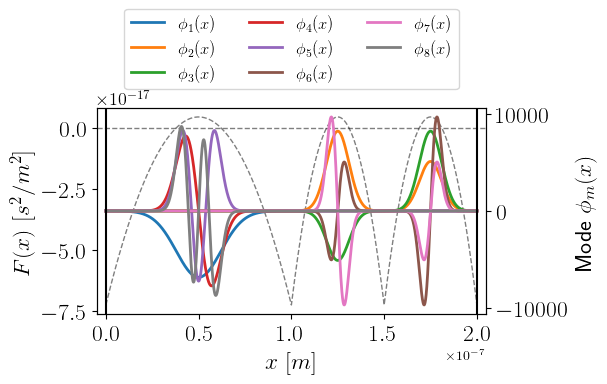

0
1
2
3
4
5
6
7


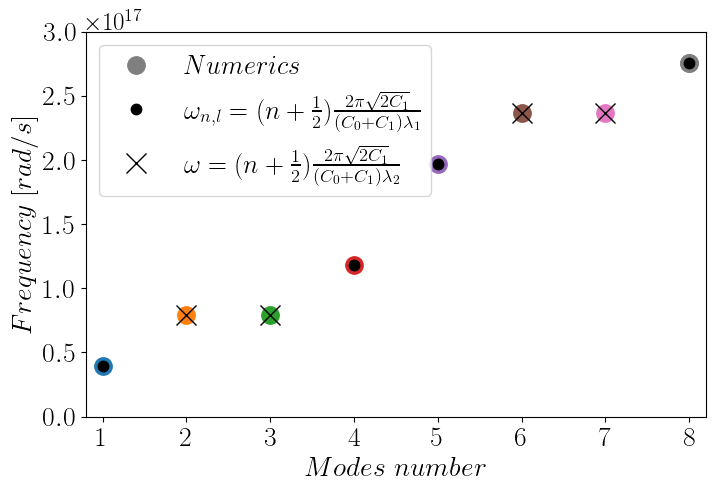

In [13]:
lam = 100e-9
# ---- sub‑medium definitions  (same numbers you used) -----------------
medium_A = (-eps0*mu0, 1.4*eps0*mu0, lam, 1)   # eps0, eps1, lam, m
medium_B = (-eps0*mu0, 1.4*eps0*mu0, lam/2, 2)

x, FFF, o0_bands, Phi_bands = slab_concat(
        params_A = medium_A,
        params_B = medium_B,
        ppp      = 400,
        n_bands  = 4)

print("First omeg0:", np.concatenate(o0_bands))

omegana0A = 0.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana1A = 1.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana2A = 2.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
omegana3A = 3.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam)
print(omegana0A,omegana1A,omegana2A,omegana3A)

omegana0B = 0.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam/2)
omegana1B = 1.5*2*np.pi*np.sqrt(2*C1)/((C0+C1)*lam/2)
print(omegana0B,omegana1B)


from matplotlib.ticker import ScalarFormatter



# --- Plot first N modes along with F(x) on a twin y-axis
N = 8  # Number of modes to plot

fonty = 17
fig, ax2 = plt.subplots(figsize=(6,4))
plt.rc('text', usetex=True)

# Plot the first N modes from flattened Phi_bands
Phi_all = np.hstack(Phi_bands)  # shape: (Nx, total_modes)

# ---------- Make an L2-rescaled copy (per column only) ----------
# Use simple trapz for L2; (optionally) trapezoid weights W if you prefer.
l2 = np.sqrt(np.trapz(Phi_all**2, x, axis=0))   # shape (K,)
Phi_L2 = Phi_all / l2  

# Twin axis for F(x)
ax1 = ax2.twinx()
ax2.tick_params(axis='x', labelsize=fonty)
ax2.tick_params(axis='y', labelsize=fonty)
ax2.plot(x, FFF, 'k--', linewidth=1,alpha=0.5)
ax2.axhline(y=0, color='k',linestyle='--',linewidth=1., alpha=0.5)
ax2.set_ylabel(r"$F(x)$ $[s^2/m^2]$", fontsize=fonty)
#ax2.legend(loc="upper left")


# Store plotted lines to extract their colors
lines = []
for n in range(N):
    line, = ax1.plot(x, Phi_L2[:, n],
                     label=fr"$\phi_{n+1}(x)$",
                     linewidth=2)
    lines.append(line)
    
ax1.tick_params(axis='x', labelsize=fonty)
ax1.tick_params(axis='y', labelsize=fonty)
ax2.set_xlabel(r'$x$ $[m]$', fontsize=fonty)
ax1.set_ylabel(r'Mode $\phi_m(x)$', fontsize=fonty)
ax1.legend(loc='lower center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=3,fontsize=fonty-5)
ax1.set_xlim(-100e-9*0.05, 2*100e-9+100e-9*0.05)


#ax = plt.gca()
ax1.xaxis.get_offset_text().set_fontsize(fonty-4)
ax1.yaxis.get_offset_text().set_fontsize(fonty-4)
ax2.yaxis.get_offset_text().set_fontsize(fonty-4)

# Add box boundaries
ax1.axvline(0, color="black", lw=1.5)
ax1.axvline(2*100e-9, color="black", lw=1.5)

#plt.title(f"First {N} modes and permittivity profile $F(x)$")
plt.tight_layout()
plt.show()

fig.savefig('Modesfinite_quantum_concatenate.png', format='png', dpi=1000, bbox_inches='tight')




fonty = 20
fig4 = plt.figure(4, figsize=(8, 5))
plt.rc('text', usetex=True)

flat_array = np.concatenate(o0_bands)  # shape: (total_modes,)
for b, oo in enumerate(flat_array[0:8],start=0):
    print(b)
    if b < N:
        color = lines[b].get_color()  # use same color as the mode line
        plt.plot(b,oo,'.',markersize=25., alpha=1,color=color)        

plt.plot(b,oo,'.',markersize=25., alpha=1,color=color,label=r'$Numerics$')
        
plt.xlabel(r'$Modes$ $number$',fontsize=fonty)
plt.ylabel(r'$Frequency$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

plt.plot(0,omegana0A,'k.',markersize=15,label=r'$\omega_{n,l}=(n+\frac{1}{2})\frac{2\pi\sqrt{2C_1}}{(C_0+C_1)\lambda_1}$')
plt.plot(3,omegana1A,'k.',markersize=15)
plt.plot(4,omegana2A,'k.',markersize=15)
plt.plot(7,omegana3A,'k.',markersize=15)
plt.plot(1,omegana0B,'kx',markersize=15,label=r'$\omega=(n+\frac{1}{2})\frac{2\pi\sqrt{2C_1}}{(C_0+C_1)\lambda_2}$')
plt.plot(2,omegana0B,'kx',markersize=15)
plt.plot(5,omegana1B,'kx',markersize=15)
plt.plot(6,omegana1B,'kx',markersize=15) 

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

#plt.xlim(-1.2*kmax, 1.2*kmax)   # set the ylim to ymin, ymax
plt.xlim(-0.2,7.2)   # set the ylim to ymin, ymax
plt.ylim(0., 3e17)   # set the ylim to ymin, ymax
plt.legend(loc="upper left",fontsize=fonty-1)
#plt.grid()
plt.yscale('linear')
plt.xticks([0,1, 2, 3,4,5,6,7], [r'$1$',r'$2$',r'$3$',r'$4$',r'$5$',r'$6$',r'$7$',r'$8$'])
fig4 = plt.gcf()
plt.show()

fig4.savefig('Energy_concatenate_1.png', format='png', dpi=1000, bbox_inches='tight')


## By Arnaud Lazarus - 06/13/2026